Import all the necessary libraries

In [ ]:
import fastf1
from fastf1.core import Laps
import math, os, json, random
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn.functional import mse_loss
torch.__version__
import sklearn
from matplotlib import pyplot as plt
import fastf1.plotting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns

In [49]:
fastf1.plotting.setup_mpl(color_scheme='fastf1')

session = fastf1.get_session(2024, 'Spanish', 'Q')

session.load()


core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.7.0]
INFO:fastf1.fastf1.core:Loading data for Spanish Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing da

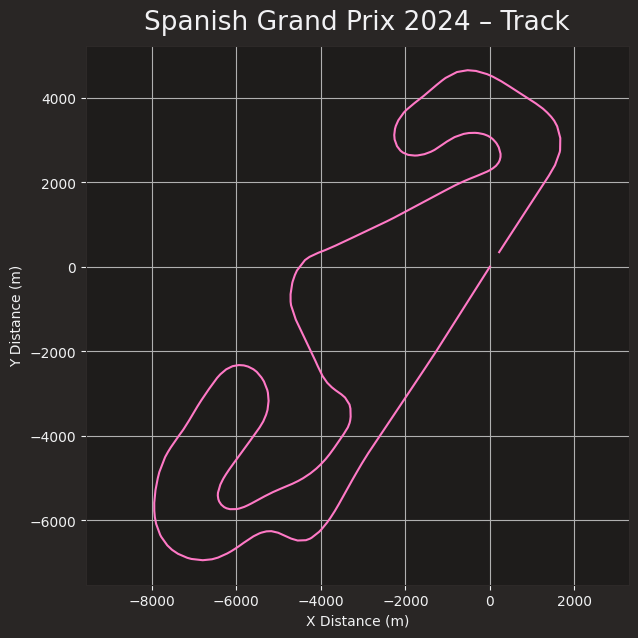

In [50]:

lap = session.laps.pick_fastest()
pos = lap.get_pos_data()
track = pos.loc[:, ('X', 'Y')].to_numpy()

origin = track[0]          # first telemetry point
shifted_track = track - origin

plt.figure(figsize=(7, 7))
plt.plot(shifted_track[:, 0], shifted_track[:, 1])

event_name = session.event['EventName']
event_year = session.event['EventDate'].year

plt.title(f"{event_name} {event_year} – Track")
plt.xlabel("X Distance (m)")
plt.ylabel("Y Distance (m)")

plt.axis('equal')
plt.grid(True)

plt.show()

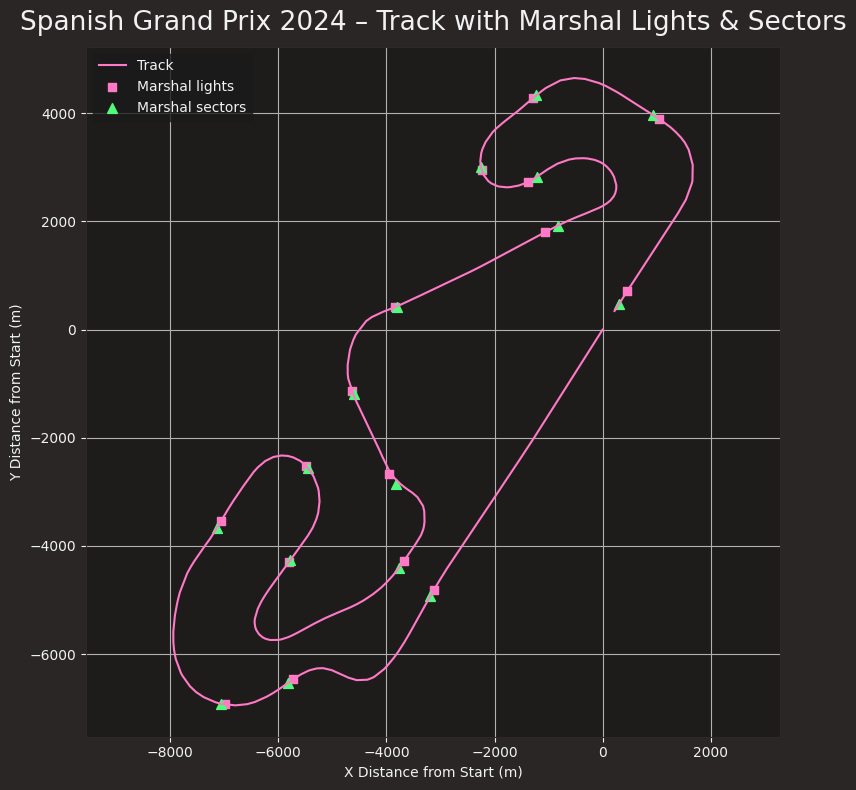

In [51]:
circuit_info = session.get_circuit_info()
lights_df = circuit_info.marshal_lights
sectors_df = circuit_info.marshal_sectors
track = track - origin

# Extract X/Y as numpy arrays
lights_xy = lights_df[['X', 'Y']].to_numpy()
sectors_xy = sectors_df[['X', 'Y']].to_numpy()

# These are already in the same rotated coordinate system as the map,
# so we only apply the same translation to move the start to (0,0)
shifted_lights = lights_xy - origin
shifted_sectors = sectors_xy - origin

# --- Plot everything ---
plt.figure(figsize=(8, 8))

# Track outline
plt.plot(track[:, 0], track[:, 1], linewidth=1.5, label='Track')

# Marshal lights (squares)
plt.scatter(
    shifted_lights[:, 0],
    shifted_lights[:, 1],
    marker='s',
    s=40,
    label='Marshal lights'
)

# Marshal sectors (triangles)
plt.scatter(
    shifted_sectors[:, 0],
    shifted_sectors[:, 1],
    marker='^',
    s=50,
    label='Marshal sectors'
)

event_name = session.event['EventName']
event_year = session.event['EventDate'].year

plt.title(f"{event_name} {event_year} – Track with Marshal Lights & Sectors")
plt.xlabel("X Distance from Start (m)")
plt.ylabel("Y Distance from Start (m)")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Normalizing the distance functipn


In [52]:
def resample_lap_by_distance(
    lap,
    n_points: int = 500,
    signals=None,
    compute_curvature: bool = False
):
    """
    Resample a FastF1 Lap's telemetry onto a fixed grid in normalized distance [0,1].
    Returns a DataFrame with columns:
        - 'u': normalized distance
        - 's': distance in meters
        - plus any telemetry in `signals` (e.g. 'Speed')
    """
    if signals is None:
        signals = ['Speed']

    # Get telemetry for this lap
    tel = lap.get_telemetry()   # Distance, Speed, X, Y, etc.

    if 'Distance' not in tel.columns:
        raise ValueError(
            "Telemetry has no 'Distance' column. "
            "Make sure session.load() included telemetry."
        )

    # Sort by distance to be safe
    tel = tel.sort_values('Distance')

    # Distance along the lap (meters)
    s = tel['Distance'].to_numpy()
    s_total = float(s[-1])

    # Normalized distance in [0, 1]
    u = s / s_total

    # Common normalized grid
    u_grid = np.linspace(0.0, 1.0, n_points)
    s_grid = u_grid * s_total

    resampled_data = {
        'u': u_grid,
        's': s_grid
    }

    # Helper: resample a telemetry column onto u_grid
    def _resample_column(col_name):
        if col_name not in tel.columns:
            return None
        values = tel[col_name].to_numpy()
        return np.interp(u_grid, u, values)

    # Resample requested signals
    for col in signals:
        vals_resampled = _resample_column(col)
        if vals_resampled is not None:
            resampled_data[col] = vals_resampled

    # (Optional) geometry and curvature can go here if needed later
    if compute_curvature and ('X' in tel.columns) and ('Y' in tel.columns):
        x_res = _resample_column('X')
        y_res = _resample_column('Y')
        resampled_data['X'] = x_res
        resampled_data['Y'] = y_res

        dx_du = np.gradient(x_res, u_grid)
        dy_du = np.gradient(y_res, u_grid)
        d2x_du2 = np.gradient(dx_du, u_grid)
        d2y_du2 = np.gradient(dy_du, u_grid)

        denom = (dx_du**2 + dy_du**2)**1.5
        with np.errstate(divide='ignore', invalid='ignore'):
            curvature = np.abs(dx_du * d2y_du2 - dy_du * d2x_du2) / denom
        curvature[~np.isfinite(curvature)] = 0.0
        resampled_data['Curvature'] = curvature

    resampled_df = pd.DataFrame(resampled_data)
    return resampled_df, s_total

In [53]:
# Resample with 500 points and a couple of extra signals
resampled_df, lap_length = resample_lap_by_distance(
    lap,
    n_points=500,
    signals=['Speed', 'Throttle', 'Brake'],
    compute_curvature=True
)

print(f"Lap length: {lap_length:.1f} m")
print(resampled_df)


Lap length: 4638.2 m
            u            s       Speed  Throttle  Brake            X  \
0    0.000000     0.000000  299.283334     100.0    0.0  1376.422486   
1    0.002004     9.295089  300.208217     100.0    0.0  1304.065537   
2    0.004008    18.590178  301.160517     100.0    0.0  1234.665493   
3    0.006012    27.885267  302.265446     100.0    0.0  1191.516463   
4    0.008016    37.180356  303.689067     100.0    0.0  1157.246866   
..        ...          ...         ...       ...    ...          ...   
495  0.991984  4601.069073  287.452546     100.0    0.0  1519.070487   
496  0.993988  4610.364162  288.755564     100.0    0.0  1488.298418   
497  0.995992  4619.659251  290.058582     100.0    0.0  1457.526348   
498  0.997996  4628.954340  291.360945     100.0    0.0  1425.174202   
499  1.000000  4638.249429  292.290001     100.0    0.0  1379.096598   

              Y     Curvature  
0   -250.736519  1.555275e-07  
1   -364.121074  8.774044e-07  
2   -472.882572  3

In [ ]:
# --- Bahrain 2024 Race ---
session_bah = fastf1.get_session(2024, 'Bahrain', 'R')
session_bah.load()
lap_bah = session_bah.laps.pick_fastest()

res_bah, len_bah = resample_lap_by_distance(
    lap_bah,
    n_points=500,
    signals=['Speed'],
    compute_curvature=False
)

# --- Spain 2024 Race ---
session_spa = fastf1.get_session(2024, 'Spain', 'R')
session_spa.load()
lap_spa = session_spa.laps.pick_fastest()

res_spa, len_spa = resample_lap_by_distance(
    lap_spa,
    n_points=500,
    signals=['Speed'],
    compute_curvature=False
)

print(f"Bahrain lap length: {len_bah:.1f} m")
print(f"Spain lap length:   {len_spa:.1f} m")

# --- Plot BOTH on normalized distance 0–1 ---
plt.figure(figsize=(10, 5))

plt.plot(
    res_bah['u'],
    res_bah['Speed'],
    label=f"{session_bah.event['EventName']} {session_bah.event['EventDate'].year}",
    linewidth=2
)

plt.plot(
    res_spa['u'],
    res_spa['Speed'],
    label=f"{session_spa.event['EventName']} {session_spa.event['EventDate'].year}",
    linewidth=2,
    linestyle='--'
)

plt.title("Fastest Lap Speed vs Normalized Distance (Bahrain vs Spain 2024)")
plt.xlabel("Normalized distance along lap (0 → 1)")
plt.ylabel("Speed (km/h)")
plt.xlim(0.0, 1.0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


For each driver, get their fastest lap time. In Qualifying for Bahrain 2024.

In [68]:
drivers = session.drivers

# Collect each driver's fastest lap as Lap objects
list_fastest_laps = []
for drv in drivers:
    drv_fastest = session.laps.pick_drivers(drv).pick_fastest()
    list_fastest_laps.append(drv_fastest)

# Sort the list of Lap objects by LapTime (fastest first)
list_fastest_laps.sort(key=lambda lap: lap['LapTime'])

In [ ]:
plt.figure(figsize=(10, 6))

# all drivers share the same 'u' grid, so grab it from any one
u_grid = next(iter(resampled_by_driver.values()))['u'].to_numpy()

for drv_code, df in resampled_by_driver.items():
    plt.plot(
        df['u'],
        df['Speed'],
        label=drv_code,
        alpha=0.7
    )

event_name = session.event['EventName']
event_year = session.event['EventDate'].year

plt.title(f"{event_name} {event_year} Qualifying – Fastest Lap Speed vs Normalized Distance")
plt.xlabel("Normalized distance along lap (0 → 1)")
plt.ylabel("Speed (km/h)")
plt.xlim(0.0, 1.0)
plt.grid(True)
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


In [70]:
# 1. Get each driver's fastest lap (you already have this)
drivers = session.drivers

list_fastest_laps = []
for drv in drivers:
    drvs_fastest_lap = session.laps.pick_drivers(drv).pick_fastest()
    list_fastest_laps.append(drvs_fastest_lap)

fastest_laps = (Laps(list_fastest_laps)
                .sort_values(by='LapTime')
                .reset_index(drop=True))

# 2. Convert LapTime (a pandas Timedelta) to seconds
fastest_laps['LapTime_s'] = fastest_laps['LapTime'].dt.total_seconds()

# 3. NORMALIZATION FUNCTION – plug in the one from your document here
# Example: min–max normalization to [0, 1]
def normalize(arr):
    arr = np.asarray(arr, dtype=float)
    return (arr - arr.min()) / (arr.max() - arr.min())

# 4. Apply your normalization to the lap times
fastest_laps['LapTime_norm'] = normalize(fastest_laps['LapTime_s'].values)

print(fastest_laps[['Driver', 'LapTime', 'LapTime_s', 'LapTime_norm']])


   Driver                LapTime  LapTime_s  LapTime_norm
0     NOR 0 days 00:01:11.383000     71.383      0.000000
1     VER 0 days 00:01:11.403000     71.403      0.009407
2     HAM 0 days 00:01:11.701000     71.701      0.149577
3     RUS 0 days 00:01:11.703000     71.703      0.150517
4     LEC 0 days 00:01:11.731000     71.731      0.163688
5     SAI 0 days 00:01:11.736000     71.736      0.166040
6     GAS 0 days 00:01:11.857000     71.857      0.222954
7     PIA 0 days 00:01:12.011000     72.011      0.295390
8     PER 0 days 00:01:12.054000     72.054      0.315616
9     OCO 0 days 00:01:12.109000     72.109      0.341486
10    ALO 0 days 00:01:12.128000     72.128      0.350423
11    BOT 0 days 00:01:12.227000     72.227      0.396990
12    HUL 0 days 00:01:12.310000     72.310      0.436030
13    STR 0 days 00:01:12.372000     72.372      0.465193
14    ZHO 0 days 00:01:12.738000     72.738      0.637347
15    MAG 0 days 00:01:12.937000     72.937      0.730950
16    TSU 0 da

We take the segmentation of the track and then evaluate Hamilton speed on each specific corner.
